In [2]:
import pandas as pd
df = pd.read_csv("churn_data_for_modeling.csv")

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charge_group,TotalAddOns,Churn_Flag,HouseholdType
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,0-12,0-35 (low),1,0,Partner only
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,25-48,36-70 (mid),2,0,Neither
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,0-12,36-70 (mid),2,1,Neither
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,25-48,36-70 (mid),3,0,Neither
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,0-12,71-90 (mid-high),0,1,Neither
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Mailed check,84.80,1990.50,No,13-24,71-90 (mid-high),5,0,Partner + Dependents
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Credit card (automatic),103.20,7362.90,No,49-72,91-120 (high),4,0,Partner + Dependents
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,Yes,Electronic check,29.60,346.45,No,0-12,0-35 (low),1,0,Partner + Dependents
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,Yes,Mailed check,74.40,306.60,Yes,0-12,71-90 (mid-high),0,1,Partner only


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'tenure_group', 'charge_group', 'TotalAddOns', 'Churn_Flag',
       'HouseholdType'],
      dtype='object')

In [5]:
df.shape

(7043, 26)

In [6]:
1526/df.shape[0]

0.21666903308249325

In [7]:
from sklearn.model_selection import train_test_split

# 1. Collapse "No internet service" to "No" across all add-on columns
addon_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
for col in addon_cols:
    df[col] = df[col].replace("No internet service", "No")

# 2. Define target and features, dropping redundant/derived columns
y = df["Churn_Flag"]
X = df.drop(columns=[
    "Churn", "Churn_Flag",
    "tenure_group", "charge_group",
    "Partner", "Dependents",
    "customerID",
])

# 3. One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# 4. Train/test split, preserving the class imbalance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4))
print("Test churn rate:", round(y_test.mean(), 4))

Train shape: (5634, 26)
Test shape: (1409, 26)
Train churn rate: 0.2654
Test churn rate: 0.2654


In [8]:
X.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'TotalAddOns', 'gender_Male', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
       'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'HouseholdType_Neither', 'HouseholdType_Partner + Dependents',
       'HouseholdType_Partner only'],
      dtype='object')

In [9]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "TotalAddOns"]

scaler = StandardScaler()

# Fit the scaler on training data only, then apply to both train and test
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [10]:
X_train

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,TotalAddOns,gender_Male,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,HouseholdType_Neither,HouseholdType_Partner + Dependents,HouseholdType_Partner only
3738,0,0.102371,-0.521976,-0.262257,0.507935,True,False,True,False,False,...,True,False,False,False,False,True,False,True,False,False
3151,0,-0.711743,0.337478,-0.503635,-0.570530,True,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
4860,0,-0.793155,-0.809013,-0.749883,0.507935,True,False,True,False,False,...,False,False,True,False,False,False,True,False,True,False
3867,0,-0.263980,0.284384,-0.172722,1.047168,False,True,False,False,False,...,True,False,True,True,True,False,False,False,False,True
3810,0,-1.281624,-0.676279,-0.989374,-1.109762,True,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,1.567778,1.470695,2.373129,1.586400,False,True,False,True,True,...,True,False,True,False,False,True,False,False,False,True
6227,0,-1.240918,-0.626504,-0.973665,-1.109762,True,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4673,1,-0.304686,1.256662,0.158344,1.047168,False,True,False,True,True,...,True,False,False,True,False,False,True,True,False,False
2710,0,-0.345392,-1.477661,-0.797075,-1.109762,False,True,False,False,False,...,False,True,False,False,True,False,False,False,False,True


In [13]:
"""
Run this in your modeling notebook AFTER fitting the scaler and
finalizing X_train (i.e., after the VIF-based column drops).

This saves everything the Streamlit dashboard needs to reproduce
your exact preprocessing pipeline on new, unseen customers.
"""


import joblib

# 1. The final trained model (skip if you already saved this)
# joblib.dump(rf_model, "churn_model.pkl")

# 2. The fitted StandardScaler
# joblib.dump(scaler, "scaler.pkl")

print("Dashboard artifacts saved: churn_model.pkl, scaler.pkl")
print("Model was trained on these columns:", list(rf_model.feature_names_in_))
print("Scaler was fit on these columns:", list(scaler.feature_names_in_))

Dashboard artifacts saved: churn_model.pkl, scaler.pkl


NameError: name 'rf_model' is not defined

In [10]:
from sklearn.linear_model import LogisticRegression

# Fit logistic regression, adjusting for class imbalance
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]  # probability of churn (class 1)

Confusion Matrix:
[[748 287]
 [ 80 294]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


ROC-AUC Score: 0.8419


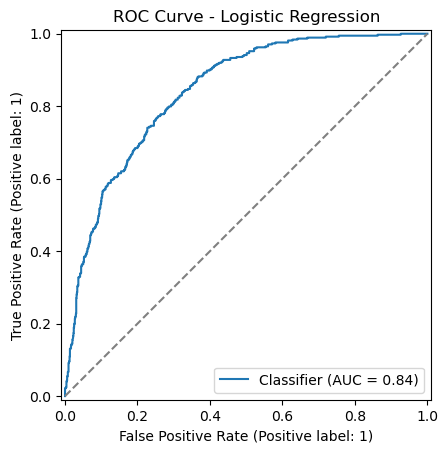

In [11]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Precision, recall, F1 for both classes
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC score
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc:.4f}")

# ROC curve plot
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("ROC Curve - Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # baseline reference
plt.show()

In [12]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
9,InternetService_Fiber optic,1.043387
3,TotalCharges,0.477582
21,PaymentMethod_Electronic check,0.399837
19,PaperlessBilling_Yes,0.334214
8,MultipleLines_Yes,0.292339
16,StreamingMovies_Yes,0.277568
15,StreamingTV_Yes,0.253358
25,HouseholdType_Partner only,0.229648
23,HouseholdType_Neither,0.210610
0,SeniorCitizen,0.151317


In [13]:
log_reg

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
X_vif.values

array([[ 0.        ,  0.10237124, -0.52197565, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.        , -0.71174346,  0.33747781, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.        , -0.79315493, -0.80901319, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 1.        , -0.30468611,  1.25666162, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.        , -0.34539184, -1.47766135, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.        , -1.07809507, -1.46936546, ...,  1.        ,
         0.        ,  0.        ]], shape=(5634, 26))

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF requires numeric input only, and works best without the target column
X_vif = X_train.astype(float)  # ensures True/False booleans are treated as numbers

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
]
vif_data.sort_values(by="VIF", ascending=False)

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
13,DeviceProtection_Yes,inf
16,StreamingMovies_Yes,inf
4,TotalAddOns,inf
6,PhoneService_Yes,inf
7,MultipleLines_No phone service,inf
11,OnlineSecurity_Yes,inf
12,OnlineBackup_Yes,inf
14,TechSupport_Yes,inf
15,StreamingTV_Yes,inf
2,MonthlyCharges,862.220177


In [17]:
X_train = X_train.drop(columns=["TotalAddOns"])
X_test = X_test.drop(columns=["TotalAddOns"])

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF requires numeric input only, and works best without the target column
X_vif = X_train.astype(float)  # ensures True/False booleans are treated as numbers

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
]
vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
2,MonthlyCharges,862.220177
5,PhoneService_Yes,370.594854
6,MultipleLines_No phone service,153.695007
8,InternetService_Fiber optic,147.849689
9,InternetService_No,103.127553
14,StreamingTV_Yes,24.045398
15,StreamingMovies_Yes,24.019507
3,TotalCharges,10.996967
1,tenure,7.641291
7,MultipleLines_Yes,7.251857


In [19]:
X_train = X_train.drop(columns=["MultipleLines_No phone service", "MonthlyCharges"])
X_test = X_test.drop(columns=["MultipleLines_No phone service", "MonthlyCharges"])

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF requires numeric input only, and works best without the target column
X_vif = X_train.astype(float)  # ensures True/False booleans are treated as numbers

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
]
vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
4,PhoneService_Yes,11.735057
2,TotalCharges,9.456770
1,tenure,7.404589
20,HouseholdType_Neither,6.450969
6,InternetService_Fiber optic,4.235506
22,HouseholdType_Partner only,4.053437
21,HouseholdType_Partner + Dependents,4.015672
7,InternetService_No,3.477759
15,Contract_Two year,3.449941
16,PaperlessBilling_Yes,2.850466


In [21]:
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

In [22]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
6,InternetService_Fiber optic,0.771581
2,TotalCharges,0.483522
18,PaymentMethod_Electronic check,0.399217
16,PaperlessBilling_Yes,0.336093
13,StreamingMovies_Yes,0.241380
5,MultipleLines_Yes,0.236070
22,HouseholdType_Partner only,0.230938
12,StreamingTV_Yes,0.215693
20,HouseholdType_Neither,0.211931
0,SeniorCitizen,0.152172


In [23]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Precision, recall, F1 for both classes
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC score
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc:.4f}")

Confusion Matrix:
[[745 290]
 [ 79 295]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


ROC-AUC Score: 0.8419


In [24]:
X_train.to_csv("X_train_processed.csv", index=False)
X_test.to_csv("X_test_processed.csv", index=False)
y_train.to_csv("y_train_processed.csv", index=False)
y_test.to_csv("y_test_processed.csv", index=False)